In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.constants import G, c
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

Loading the dataset from a CSV file.

In [ ]:
df = pd.read_csv("/content/sample_data/Skyserver_Radial6_16_2025 10_34_29 AM.csv")

Grouping data by object ID and calculating the mean redshift and other properties.

In [ ]:
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',
    'ra': 'first',
    'dec': 'first',
    'proj_sep': 'first',
    'rmag': 'first'
}).reset_index()

This cell generates and displays a histogram of the redshift distribution for all galaxies in the `averaged_df` DataFrame. It sets the title, labels, and adds a grid for better visualization.

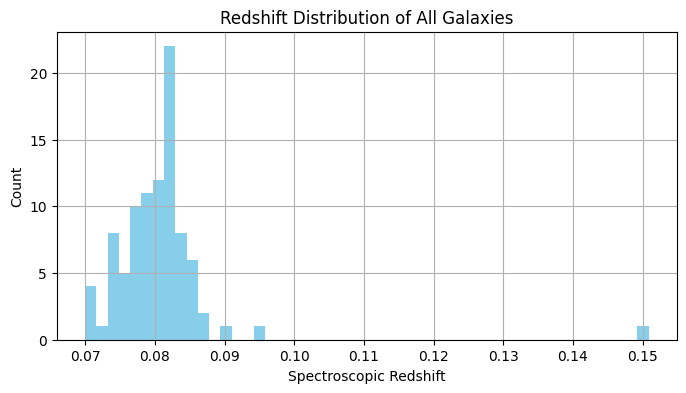

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(averaged_df['specz'], bins=50, color='skyblue')
plt.title("Redshift Distribution of All Galaxies")
plt.xlabel("Spectroscopic Redshift")
plt.ylabel("Count")
plt.grid(True)
plt.show()


 This cell calculates the mean and standard deviation of the redshift. It then defines the redshift ranges corresponding to 1, 2, and 3-sigma cuts from the mean. Cluster members are identified using the 3-sigma cut. Finally, it plots the redshift distribution with vertical lines indicating the mean and the sigma cut boundaries.



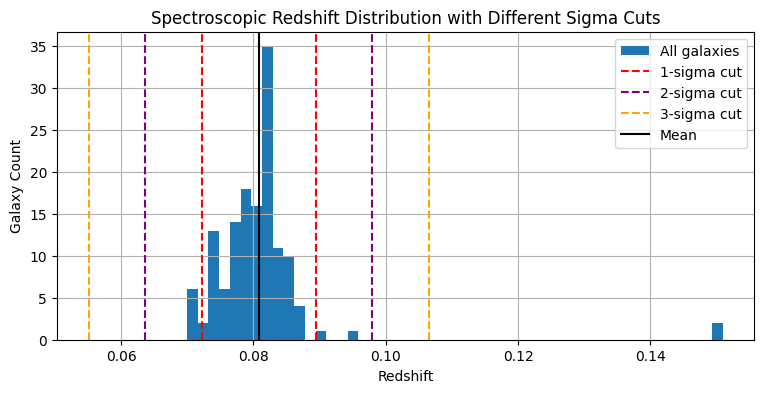

Number of cluster galaxies selected: 84


In [ ]:
### Identify Cluster Members Using 3-Sigma Cut
mean_z = averaged_df['specz'].mean()
std_z = averaged_df['specz'].std()

# 1-sigma cut (originally 3-sigma in the user code)
z_min_1sigma = mean_z - 1 * std_z
z_max_1sigma = mean_z + 1 * std_z

# 2-sigma cut
z_min_2sigma = mean_z - 2 * std_z
z_max_2sigma = mean_z + 2 * std_z

# 3-sigma cut
z_min_3sigma = mean_z - 3 * std_z
z_max_3sigma = mean_z + 3 * std_z

# Identify cluster members for 3-sigma cut
cluster_members = averaged_df[(averaged_df['specz'] >= z_min_1sigma) & (averaged_df['specz'] <= z_max_1sigma)].copy()

# Plotting the distribution with different sigma cuts
plt.figure(figsize=(9, 4))
plt.hist(df['specz'], bins=50, label='All galaxies')

# Plot 1-sigma cut
plt.axvline(z_min_1sigma, color='red', linestyle='--', label='1-sigma cut')
plt.axvline(z_max_1sigma, color='red', linestyle='--')

# Plot 2-sigma cut
plt.axvline(z_min_2sigma, color='purple', linestyle='--', label='2-sigma cut')
plt.axvline(z_max_2sigma, color='purple', linestyle='--')

# Plot 3-sigma cut
plt.axvline(z_min_3sigma, color='orange', linestyle='--', label='3-sigma cut')
plt.axvline(z_max_3sigma, color='orange', linestyle='--')

plt.axvline(mean_z, color='black', linestyle='-', label='Mean')
plt.legend()
plt.title('Spectroscopic Redshift Distribution with Different Sigma Cuts')
plt.xlabel('Redshift')
plt.ylabel('Galaxy Count')
plt.grid(True)
plt.show()
print(f"Number of cluster galaxies selected: {len(cluster_members)}")




*   Calculating peculiar velocity for cluster members.

*   Printing cluster redshift, sample velocities, and velocity dispersion.
*   Plotting the peculiar velocity distribution.





Cluster Redshift: 0.08031

Peculiar Velocity:
       specz     velocity
0  0.082457   594.880099
1  0.081218   251.699909
2  0.079564  -207.264517
3  0.080842   147.260830
4  0.084575  1181.056643

Velocity Dispersion: 950.1253 km/s



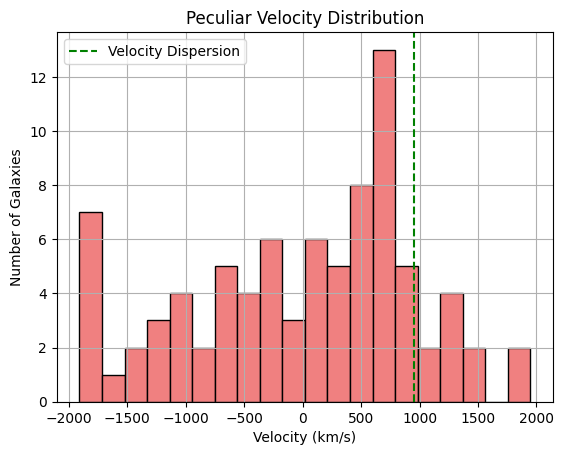

In [ ]:
z = cluster_members['specz']
z_cluster = cluster_members['specz'].mean()

# Relativistic velocity calculation
numerator = (1 + z)**2 - (1 + z_cluster)**2
denominator = (1 + z)**2 + (1 + z_cluster)**2
cluster_members['velocity'] = c.value * (numerator / denominator) /1000

print(f"Cluster Redshift: {z_cluster:.5f}\n")
print("Peculiar Velocity:\n", cluster_members[['specz', 'velocity']].head())
velocity_dispersion = cluster_members['velocity'].std()
print(f"\nVelocity Dispersion: {velocity_dispersion:.4f} km/s\n")

plt.hist(cluster_members['velocity'], bins=20, color='lightcoral', edgecolor='black')
plt.axvline(velocity_dispersion, color='green', linestyle='--', label='Velocity Dispersion')
plt.title("Peculiar Velocity Distribution")
plt.xlabel("Velocity (km/s)")
plt.ylabel("Number of Galaxies")
plt.legend()
plt.grid(True)
plt.show()


This cell calculates the angular diameter distance to the cluster using a Taylor expansion approximation and a given cosmology. It then estimates the physical radius of the cluster based on the angular diameter distance and the 90th percentile of the projected angular separation.

In [ ]:
# Cluster redshift
z = cluster_members['specz'].mean()

# Hubble constant
H0 = cosmo.H(0)  # Hubble constant in (km/s)/Mpc
H0_si = H0.to('1/s').value  # Convert to 1/s

# Deceleration parameter
q0 = -0.534

# Speed of light in m/s
c_val = c.value

# Co-moving distance using Taylor expansion
r = (c.value * z / H0_si) * (1 - (z / 2) * (1 + q0))  # in meters

# Angular diameter distance
D_A = r / (1 + z)

# Convert to Mpc
D_A_Mpc = D_A / 3.0857e22
print(f"Angular Diameter Distance: {D_A_Mpc:.2f} Mpc")

angular_radius_arcmin = cluster_members['proj_sep'].quantile(0.9)
theta_rad = angular_radius_arcmin * np.pi / (180 * 60)

# Physical cluster radius
r_mpc = D_A_Mpc * theta_rad
print(f"Estimated Physical Cluster Radius: {r_mpc:.2f} Mpc")


Angular Diameter Distance: 323.23 Mpc
Estimated Physical Cluster Radius: 0.84 Mpc


Plotting the distribution of projected angular separation for cluster members.

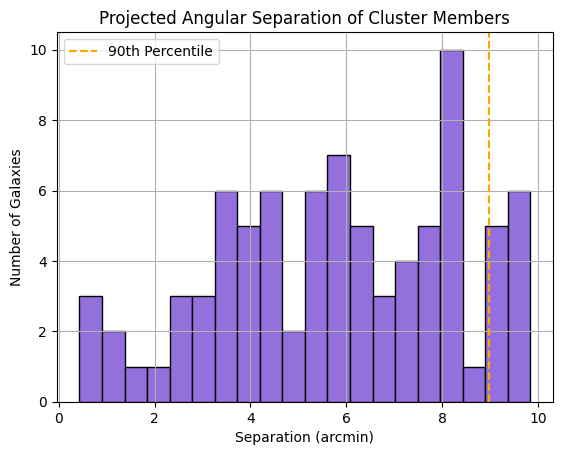

In [ ]:
plt.hist(cluster_members['proj_sep'], bins=20, color='mediumpurple', edgecolor='black')
plt.axvline(angular_radius_arcmin, color='orange', linestyle='--', label='90th Percentile')
plt.title("Projected Angular Separation of Cluster Members")
plt.xlabel("Separation (arcmin)")
plt.ylabel("Number of Galaxies")
plt.legend()
plt.grid(True)
plt.show()



*   Estimating the dynamical mass of the cluster using the virial theorem
*   Converting the mass to solar masses.



In [ ]:
### Estimate Dynamical Mass
sigma_m_per_s = velocity_dispersion * 1000  # km/s to m/s
R_m = r_mpc * 3.0857e22  # Mpc to meters

# Virial mass estimate in kg
mass_kg = (3 * sigma_m_per_s**2 * R_m) / G.value

# Convert to solar masses
solar_mass_kg = 2*10**30
mass_solar = mass_kg / solar_mass_kg

print(f"Dynamical Mass of Cluster: {mass_solar:.2e} M☉")

Dynamical Mass of Cluster: 5.29e+14 M☉




*   Calculating the luminous mass of the cluster based on luminosity and a mass-to-light ratio.
*   Comparing dynamical and luminous mass.



In [ ]:
# Get luminosity distance in parsecs
z_cluster = cluster_members['specz'].mean()
D_L_pc = cosmo.luminosity_distance(z_cluster).to('pc').value

# Convert apparent to absolute magnitude
m_r = cluster_members['rmag']
M_r = m_r - 5 * np.log10(D_L_pc / 10)

# Compute luminosity relative to Sun
M_r_sun = 4.67
luminosities = 10 ** (-0.4 * (M_r - M_r_sun))

# Estimate luminous mass with M/L = 10
M_L_ratio = 10
luminous_mass = np.sum(luminosities) * M_L_ratio

print(f"Luminous Mass Estimate: {luminous_mass:.2e} M☉")

print("Mass ratio Mdyn/Mlum = ", mass_solar/luminous_mass)

Luminous Mass Estimate: 2.27e+13 M☉
Mass ratio Mdyn/Mlum =  23.34194872395286


Dynamical Mass M
dyn
​
  = 9.00×10 ^
14
 M⊙
​

Luminous Mass M
lum
​
  = 2.36×10 ^
13
 M⊙
​


Fraction of Mass That Is Luminous:

f
lum
​
  = M
lum
​
 /M
dyn =

2.36×10 ^
13
/9.00×10 ^
14
≈ 0.0262

Therefore, only 2.62% of the total mass is due to luminous matter.
The remaining, 100%−2.62% ≈ 97.38%, is not visible, which is attributed to non-luminous hot gases or dark matter.

This cell generates a scatter plot showing the spatial distribution of the cluster members on the sky, using their Right Ascension and Declination coordinates.

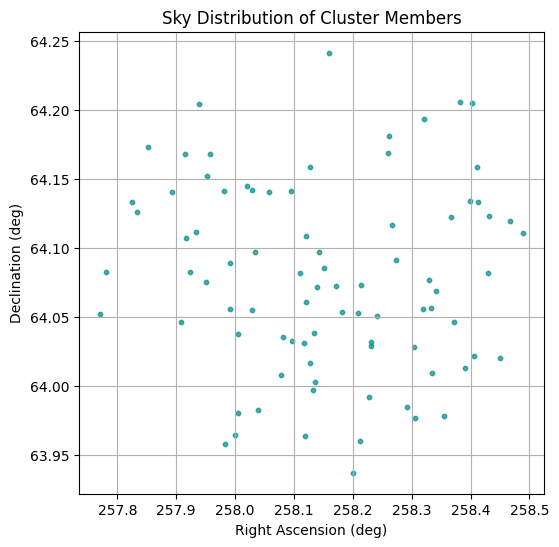

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(cluster_members['ra'], cluster_members['dec'], s=10, alpha=0.7, color='darkcyan')
plt.title("Sky Distribution of Cluster Members")
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.grid(True)
plt.show()